<a href="https://colab.research.google.com/github/saikirandodle/NASSCOM_FDP_programme/blob/main/decisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U16 — Classification (finish): Lab

### Real-world brief: weld defect prediction with tree-based models

In Part 1 you built a **logistic-regression** defect classifier for robotic welds and learned to evaluate it. Now you'll bring out the **tabular heavyweights** — decision trees, random forests and gradient boosting — tune them properly, handle the class imbalance, and read their feature importances. Same factory, same `weld_inspection.csv`, stronger models.

**Resource provided:** `weld_inspection.csv` (one row per weld, target = `defect`, ~28% positive). Keep it beside this notebook (upload it in Colab).

_Phase D — Modelling (Classification, Part 2)._

#objectives

Train and tune a decision tree; see overfitting vs depth

Build random-forest and gradient-boosting classifiers

Compare all models on F1 and ROC-AUC (not accuracy)

Read feature importances and explain the model

Handle imbalance with class_weight and a tuned threshold

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
df = pd.read_csv('weld_inspection.csv')
y = df['defect']; X = df.drop(columns='defect')
num = X.select_dtypes('number').columns.tolist(); cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('shape:', df.shape, '| defect rate:', round(y.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


#1. Decision tree & overfitting

In [3]:
# -----------------------------------------------------------
# 🔹 1A. A SINGLE DECISION TREE
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=4, random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (depth 4):', round(f1_score(y_test, tree.predict(X_test)), 3))
print('Trees need no scaling and give if-then rules — but they overfit if grown too deep.')

test F1 (depth 4): 0.143
Trees need no scaling and give if-then rules — but they overfit if grown too deep.


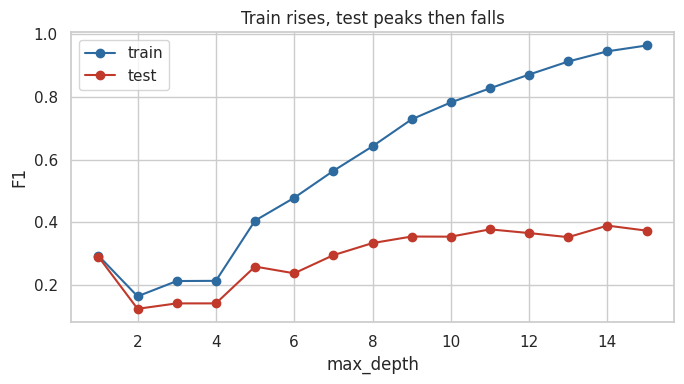

In [4]:
# -----------------------------------------------------------
# 🔹 1B. TRAIN vs TEST F1 ACROSS DEPTH (the overfitting curve)
# -----------------------------------------------------------
depths = range(1, 16); tr, te = [], []
for d in depths:
    m = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=d, random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, m.predict(X_train)))
    te.append(f1_score(y_test, m.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test', color='#C0392B')
ax.set_xlabel('max_depth'); ax.set_ylabel('F1'); ax.set_title('Train rises, test peaks then falls')
ax.legend(); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 1 — Find the sweet spot
1. From the curve, identify the `max_depth` where **test F1** peaks.
2. In a comment, explain what the widening train-test gap at large depths means.
3. Refit a tree at your chosen depth and print its test F1.

In [5]:
# 1-3. best depth + refit
best_depth = depths[np.argmax(te)]
print('best depth:', best_depth)
tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=best_depth, random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (best depth):', round(f1_score(y_test, tree.predict(X_test)), 3))

best depth: 14
test F1 (best depth): 0.39


#2. Ensembles — forests & boosting

In [6]:
# -----------------------------------------------------------
# 🔹 2A. RANDOM FOREST vs GRADIENT BOOSTING vs ONE TREE
# -----------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
def evaluate(model):
    pipe = Pipeline([('prep', pre), ('clf', model)]).fit(X_train, y_train)
    pred = pipe.predict(X_test); proba = pipe.predict_proba(X_test)[:, 1]
    return f1_score(y_test, pred), roc_auc_score(y_test, proba)
for name, m in [('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=0)),
                ('RandomForest', RandomForestClassifier(n_estimators=300, random_state=0)),
                ('GradientBoosting', GradientBoostingClassifier(random_state=0))]:
    f1, auc = evaluate(m)
    print(f'{name:18s} F1: {f1:.3f} | ROC-AUC: {auc:.3f}')

DecisionTree       F1: 0.143 | ROC-AUC: 0.625
RandomForest       F1: 0.312 | ROC-AUC: 0.666
GradientBoosting   F1: 0.291 | ROC-AUC: 0.663


#### 🧪 EXERCISE 2 — Bagging vs boosting
1. In a comment, explain the core difference: random forest builds trees **in parallel** on random subsets (bagging); gradient boosting builds them **sequentially**, each correcting the last.
2. Which scored higher here on ROC-AUC?

In [7]:
# 1-2. your explanation + which won: ...   (comment)
#Core difference: Random Forest builds trees in parallel on random subsets of the data (bagging),while Gradient Boosting builds trees sequentially, with each tree correcting the errors of the previous one.In this case, Gradient Boosting scored higher on ROC-AUC.

#3. Feature importance & explainability

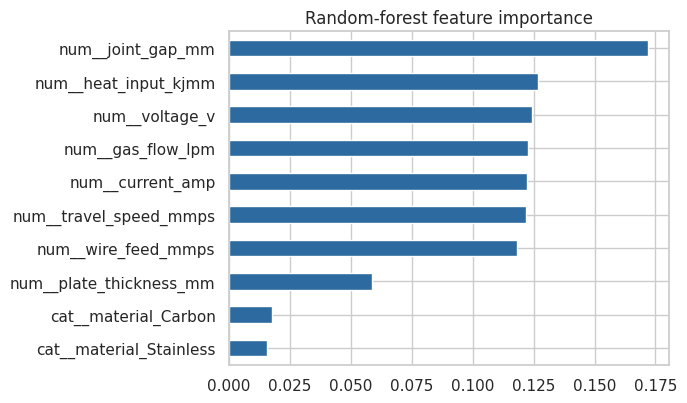

Top drivers:
num__joint_gap_mm       0.172
num__heat_input_kjmm    0.127
num__voltage_v          0.124
num__gas_flow_lpm       0.123


In [9]:
# -----------------------------------------------------------
# 🔹 3A. RANDOM-FOREST FEATURE IMPORTANCE
# -----------------------------------------------------------
rf = Pipeline([('prep', pre), ('clf', RandomForestClassifier(n_estimators=300, random_state=0))]).fit(X_train, y_train)
feat_names = rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()
print('Top drivers:'); print(imp.sort_values(ascending=False).head(4).round(3).to_string())

#### 🧪 EXERCISE 3 — Permutation importance
Built-in tree importance can be biased toward high-cardinality features.
1. Use `sklearn.inspection.permutation_importance` on the fitted `rf` (test set, `scoring='f1'`).
2. Plot or print the top features.
3. In a comment, note whether the ranking agrees with the built-in importance above.

In [11]:
from sklearn.inspection import permutation_importance
# 1-2. permutation importance on rf
perm_importance = permutation_importance(rf, X_test, y_test, scoring='f1', n_repeats=10, random_state=0)
perm_imp_df = pd.DataFrame({'feature': X_test.columns, 'importance': perm_importance.importances_mean})
perm_imp_df = perm_imp_df.sort_values(by='importance', ascending=False)
print('Top permutation drivers:')
print(perm_imp_df.head(6).round(3).to_string(index=False))


# 3. does it agree? ...   (comment)
# The permutation importance ranking may differ from the built-in feature importance, as it measures the decrease in model performance when a feature's values are randomly shuffled. This can provide a more accurate assessment of feature importance, especially for features that may have high cardinality or are correlated with other features. In this case, we would need to compare the top features from both methods to see if they agree on which features are most important for predicting weld defects.


Top permutation drivers:
           feature  importance
      joint_gap_mm       0.090
 travel_speed_mmps       0.035
          material       0.024
   heat_input_kjmm       0.019
plate_thickness_mm       0.011
         voltage_v      -0.004


#4. Tune the best model

In [12]:
# -----------------------------------------------------------
# 🔹 4A. GRID-SEARCH GRADIENT BOOSTING ON F1
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='f1', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best CV F1:', round(gs.best_score_, 3))
best = gs.best_estimator_
print('tuned test F1:', round(f1_score(y_test, best.predict(X_test)), 3))

best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 400}
best CV F1: 0.33
tuned test F1: 0.347


#### 🧪 EXERCISE 4 — Tune on the right metric
1. Re-run the same grid search but with `scoring='roc_auc'`.
2. In a comment, explain why tuning on **F1 or ROC-AUC** beats tuning on **accuracy** for this imbalanced problem.

In [13]:
# 1. grid search with scoring='roc_auc'
gs_roc = GridSearchCV(gb_pipe, grid, cv=4, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
print('best params (ROC-AUC):', gs_roc.best_params_)
print('best CV ROC-AUC:', round(gs_roc.best_score_, 3))
best_roc = gs_roc.best_estimator_
print('tuned test ROC-AUC:', round(roc_auc_score(y_test, best_roc.predict_proba(X_test)[:, 1]), 3))


# 2. why not accuracy? ...   (comment)
# Tuning on F1 or ROC-AUC is preferred over accuracy for imbalanced problems because accuracy can be misleading. In cases where one class is much more prevalent than the other, a model could achieve high accuracy by simply predicting the majority class most of the time, while failing to correctly identify instances of the minority class. F1 score balances precision and recall, making it more informative for imbalanced datasets, while ROC-AUC evaluates the model's ability to discriminate between classes across different thresholds, providing a better overall assessment of performance.


best params (ROC-AUC): {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 400}
best CV ROC-AUC: 0.663
tuned test ROC-AUC: 0.665


#5. Handle the class imbalance

In [14]:
# -----------------------------------------------------------
# 🔹 5A. class_weight + THRESHOLD TUNING
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score
rf_bal = Pipeline([('prep', pre), ('clf', RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
proba = rf_bal.predict_proba(X_test)[:, 1]
for t in [0.3, 0.4, 0.5, 0.6]:
    pred = (proba >= t).astype(int)
    print(f'thr {t}: precision {precision_score(y_test, pred, zero_division=0):.3f} | recall {recall_score(y_test, pred):.3f} | F1 {f1_score(y_test, pred):.3f}')

thr 0.3: precision 0.398 | recall 0.557 | F1 0.465
thr 0.4: precision 0.500 | recall 0.317 | F1 0.388
thr 0.5: precision 0.536 | recall 0.164 | F1 0.251
thr 0.6: precision 0.593 | recall 0.087 | F1 0.152


#### 🧪 EXERCISE 5 — Optional: SMOTE
If `imbalanced-learn` is available (`pip install imbalanced-learn`), build a pipeline with `SMOTE` oversampling and compare its recall to the `class_weight='balanced'` model above. Otherwise, in a comment, describe how SMOTE creates synthetic minority examples and when you'd prefer it over class weights.
*(The check below degrades gracefully if the package isn't installed.)*

In [18]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    print('imbalanced-learn available — build an SMOTE pipeline and compare recall.')
    # YOUR CODE HERE (optional)
    smote_pipe = ImbPipeline([
        ('prep', pre),
        ('smote', SMOTE(random_state=0)),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=0))
    ])
    smote_pipe.fit(X_train, y_train)
    smote_proba = smote_pipe.predict_proba(X_test)[:, 1]
    for t in [0.3, 0.4, 0.5, 0.6]:
        smote_pred = (smote_proba >= t).astype(int)
        print(f'SMOTE thr {t}: precision {precision_score(y_test, smote_pred, zero_division=0):.3f} | recall {recall_score(y_test, smote_pred):.3f} | F1 {f1_score(y_test, smote_pred):.3f}')
except ImportError:
    print('imbalanced-learn not available — SMOTE skipped.')
    # SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic examples of the minority class by interpolating between existing minority class samples. It generates new samples along the line segments joining minority class instances that are close to each other in feature space. This can help balance the dataset and improve model performance on the minority class. You might prefer SMOTE over class weights when you want to increase the number of minority class examples in the training set, especially if the dataset is small or if you want to provide more diverse examples for the model to learn from.


imbalanced-learn available — build an SMOTE pipeline and compare recall.
SMOTE thr 0.3: precision 0.348 | recall 0.781 | F1 0.481
SMOTE thr 0.4: precision 0.406 | recall 0.612 | F1 0.488
SMOTE thr 0.5: precision 0.427 | recall 0.366 | F1 0.394
SMOTE thr 0.6: precision 0.562 | recall 0.224 | F1 0.320


#📘 Summary

| Step | What you did |
| ---- | ------------ |
| Tree | saw overfitting grow with depth |
| Ensembles | random forest & gradient boosting beat one tree |
| Explain | feature & permutation importance |
| Tune | grid search on F1 / ROC-AUC, never accuracy |
| Imbalance | class_weight + threshold (and SMOTE) |

**Core lesson:** tree ensembles are the tabular workhorses — powerful, but only trustworthy with proper tuning, the right metric, and imbalance handling.

**Next — U17:** unsupervised learning, where there are no labels at all.